In [197]:
#### import ####
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
## statsmodels ##
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
## acf, pacf ##
from statsmodels.tsa.stattools import pacf, acf
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.api import VAR
## garch
from arch import arch_model

# Model Fit

In [ ]:
data = pd.read_csv('var_ipc.csv')
n, _ = data.shape

# parce date
data['date'] = pd.to_datetime(data['date'])

In [ ]:
arma = ARIMA(
    data['var_ipc'],
    order=(1,0,1)
)
fit = arma.fit()

In [ ]:
fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                var_ipc   No. Observations:                  360
Model:                 ARIMA(1, 0, 1)   Log Likelihood                  89.419
Date:                Wed, 15 Apr 2026   AIC                           -170.837
Time:                        14:31:31   BIC                           -155.293
Sample:                             0   HQIC                          -164.657
                                - 360                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1317      0.028      4.692      0.000       0.077       0.187
ar.L1          0.9247      0.033     27.905      0.000       0.860       0.990
ma.L1         -0.7952      0.054    -14.652      0.000      -0.902      -0.689
sigma2         0.0356      0.002     18.212      0.000       0.032       0.039
===================================================================================
Ljung-Box (L1) (Q):                   0.27   Jarque-Bera (JB):                53.87
Prob(Q):                              0.60   Prob(JB):                         0.00
Heteroskedasticity (H):               1.79   Skew:                            -0.12
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.88
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

# Inverse Roots

In [ ]:
1/fit.arroots, 1/fit.maroots

(array([0.92473456]), array([0.79524914]))

# PACF and ACF

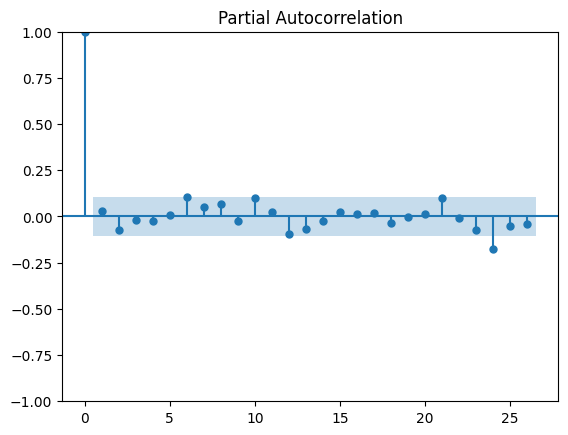

In [143]:
residuals = fit.resid
pacf_fig = plot_pacf(residuals)
plt.show()

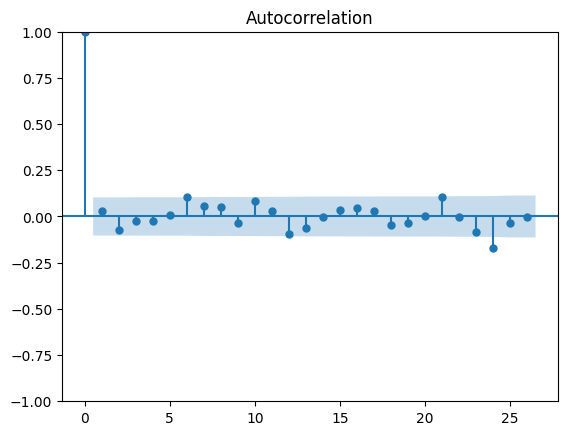

In [144]:
acf_fig = plot_acf(residuals)
plt.show()

## Impluse response

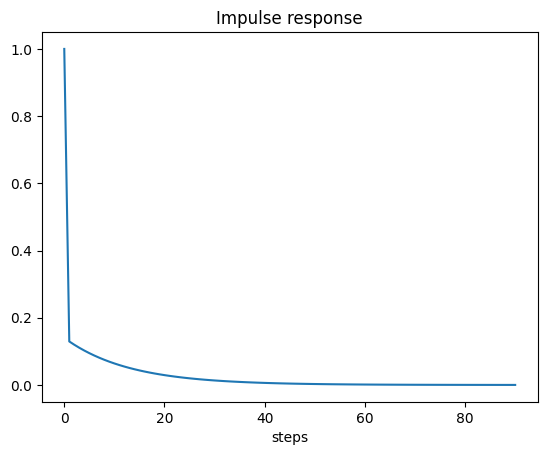

In [145]:
imp_response = fit.impulse_responses(int(n/4))
plt.plot(imp_response)
plt.title('Impulse response')
plt.xlabel('steps');

In [146]:
acorr_ljungbox(fit.resid)['lb_pvalue']

1     0.604093
2     0.331133
3     0.492176
4     0.627785
5     0.756833
6     0.328794
7     0.332176
8     0.340709
9     0.395096
10    0.281037
Name: lb_pvalue, dtype: float64

In [147]:
plo

NameError: name 'plo' is not defined

# GARCH

In [ ]:
garch_base = arch_model(data['var_ipc'], mean='Zero', lags=1, vol='GARCH', p=1, q=1).fit(disp=False)

c:\Users\José\AppData\Local\Programs\Python\Python311\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.03985. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [ ]:
garch = arch_model(fit.resid, mean='Zero', vol='GARCH', p=1, q=1).fit(disp=False)

c:\Users\José\AppData\Local\Programs\Python\Python311\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.03562. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [ ]:
garch_base.pvalues

omega       8.325067e-02
alpha[1]    3.855780e-03
beta[1]     4.168697e-25
Name: pvalues, dtype: float64

In [ ]:
garch.pvalues

omega       0.217991
alpha[1]    0.102603
beta[1]     0.000001
Name: pvalues, dtype: float64

In [ ]:
garch_base.aic, garch_base.bic

(-57.88096441526536, -46.22265232091489)

In [ ]:
garch.aic, garch.bic

(-190.72818867476323, -179.06987658041277)

In [ ]:
garch.params

omega       0.004616
alpha[1]    0.116884
beta[1]     0.757214
Name: params, dtype: float64

In [ ]:
garch_t = arch_model(fit.resid, mean='Zero', vol='GARCH', p=1, q=1, dist = 't').fit(disp=False)

garch_ged = arch_model(fit.resid, mean='Zero', vol='GARCH', p=1, q=1, dist = 'ged').fit(disp=False)

c:\Users\José\AppData\Local\Programs\Python\Python311\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.03562. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
c:\Users\José\AppData\Local\Programs\Python\Python311\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.03562. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


In [ ]:
print(
    pd.DataFrame([garch.pvalues, garch_t.pvalues, garch_ged.pvalues], index = ['gaussian', 't-student', 'GED']).T
)

          gaussian     t-student           GED
omega     0.217991  7.350181e-02  1.229680e-01
alpha[1]  0.102603  6.512143e-02  7.979812e-02
beta[1]   0.000001  4.068092e-07  3.843835e-07
nu             NaN  9.926439e-06  1.824966e-29


In [ ]:
print(
    pd.DataFrame(
    [[garch.aic, garch_t.aic, garch_ged.aic],[garch.bic, garch_t.bic, garch_ged.bic]],
    index = ['AIC', 'BIC'],
    columns=['gaussian', 't-student', 'GED']
))

       gaussian   t-student         GED
AIC -190.728189 -210.508049 -207.116110
BIC -179.069877 -194.963633 -191.571694


In [ ]:
garch_t.params

omega       0.006282
alpha[1]    0.135997
beta[1]     0.699297
nu          5.220113
Name: params, dtype: float64

In [ ]:
garch_t.params

omega       0.006282
alpha[1]    0.135997
beta[1]     0.699297
nu          5.220113
Name: params, dtype: float64

### Fitted plot

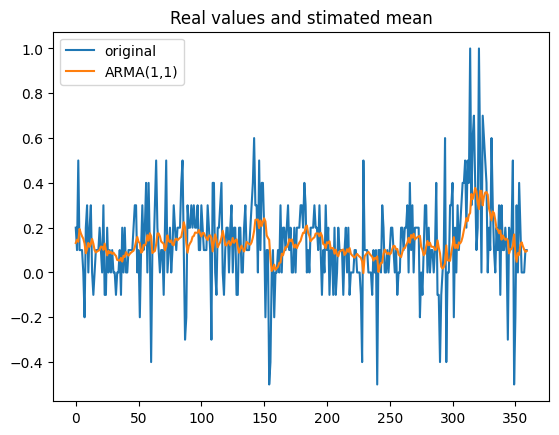

In [ ]:
plt.plot(data['var_ipc'], label = 'original')
plt.plot(fit.fittedvalues, label = 'ARMA(1,1)')
plt.title('Real values and stimated mean')
plt.legend();

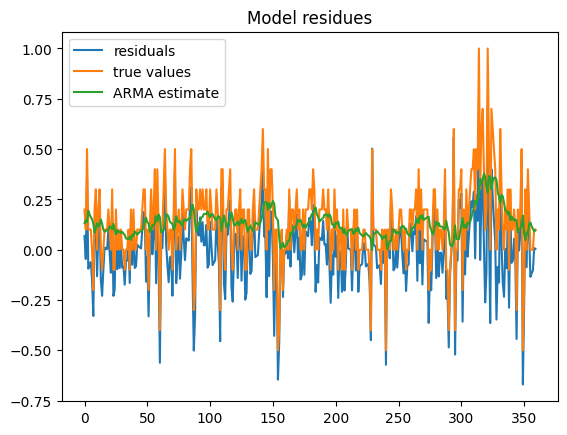

In [151]:
plt.plot(fit.resid, label = 'residuals')
plt.plot(data['var_ipc'], label= 'true values')
plt.plot(fit.fittedvalues, label = 'ARMA estimate')
plt.title('Model residues')
plt.legend();

Text(0.5, 1.0, 'Standardised residuals of GARCH(1,1)')

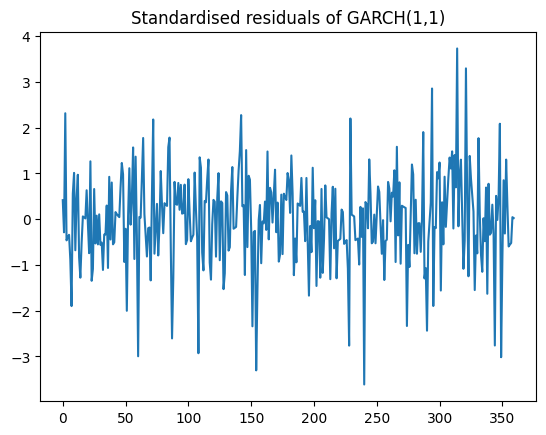

In [153]:
plt.plot(garch_t.std_resid)
plt.title('Standardised residuals of GARCH(1,1)')

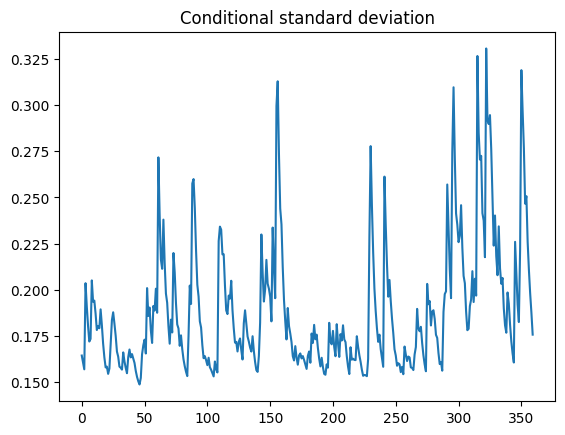

In [154]:
plt.plot(garch_t.conditional_volatility)
plt.title('Conditional standard deviation');

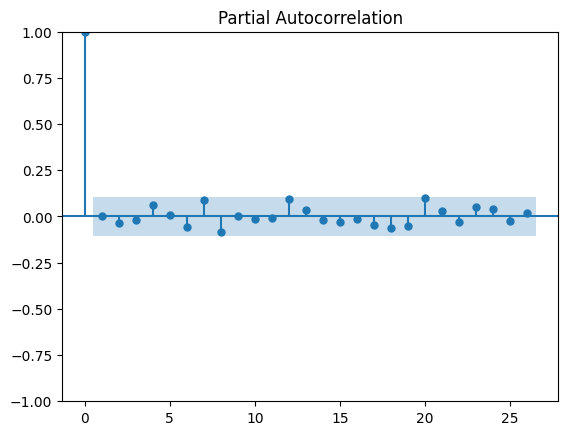

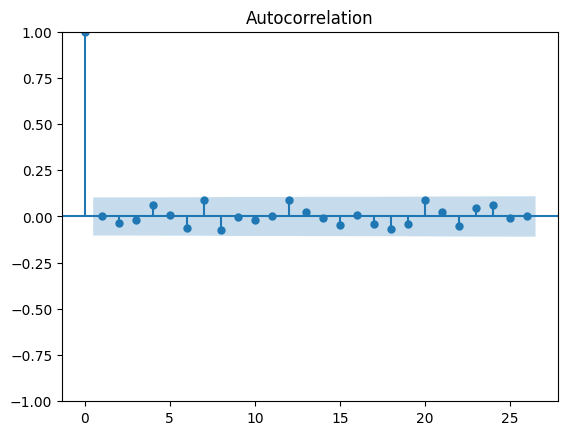

In [159]:
sq_std_res = (garch_t.std_resid)**2
_ = plot_pacf(sq_std_res)
_ = plot_acf(sq_std_res)
plt.show()

5.200597344787632

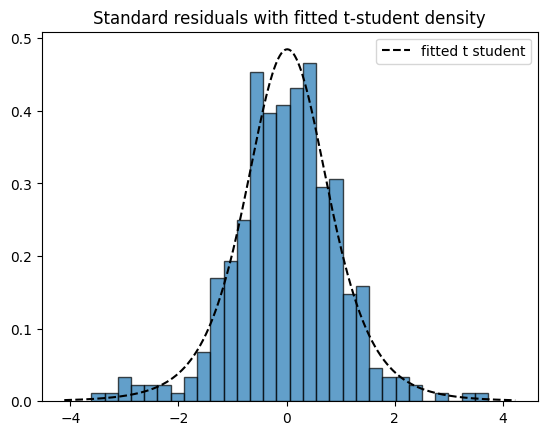

In [177]:
df_est, loc_est, scale_est = stats.t.fit(garch_t.std_resid)

std_res = garch_t.std_resid

fig, ax = plt.subplots()
ax.hist(std_res,bins=30,density=True, edgecolor='black', alpha = 0.7)

x = np.linspace(std_res.min() - 0.5, std_res.max() + 0.5, 300)
pdf_fitted = stats.t.pdf(x, df_est, loc_est, scale_est)

ax.plot(x, pdf_fitted, '--', color='black', label  = 'fitted t student')
plt.title('Standard residuals with fitted t-student density')
plt.legend();
df_est

In [181]:
lm_stat, lm_pval, f_stat, f_pval = het_arch(garch_t.resid, nlags=10)
f_pval

0.003795855212138648

In [180]:
lm_stat, lm_pval, f_stat, f_pval = het_arch(garch_t.std_resid, nlags=10)
f_pval

0.5901424751749809

# Racine Unitaire

In [196]:
[adfuller(data['var_ipc'], regression ='n')[1],
adfuller(data['var_ipc'], regression = 'c')[1],
adfuller(data['var_ipc'], regression= 'ct')[1],
adfuller(data['var_ipc'], regression = 'ctt')[1]]

[0.020509962068361656,
 0.0001218598848157226,
 0.0007473219854898913,
 0.003640628714878265]

# VAR